In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
climate_data = pd.read_csv('../../data_files/data/climate_api_data_2016_2024.csv')
fire_data = pd.read_csv('../../data_files/data/inpe_fire_counts_data_2016_2024.csv')
defor_data = pd.read_csv('../../data_files/data/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')

# Merge data
climate_data = climate_data.merge(fire_data[['date', 'fire_counts']], on='date', how='left')
climate_data = climate_data.merge(defor_data[['date', 'total_degradation']], on='date', how='left')
climate_data['fire_counts'] = climate_data['fire_counts'].fillna(0)
climate_data['total_degradation'] = climate_data['total_degradation'].fillna(0)

# Extract actual environmental variables
temp_actual = climate_data['temp_med'].dropna().values
humid_actual = climate_data['umid_min'].dropna().values
rain_actual = climate_data['precip_med'].dropna().values
fire_actual = climate_data['fire_counts'].values
defor_actual = climate_data['total_degradation'].values

print('Environmental Data Summary (Manaus, Brazil 2016-2024)')
print('='*60)
print(f"Temperature:  min={temp_actual.min():.1f}°C, max={temp_actual.max():.1f}°C, mean={temp_actual.mean():.1f}°C")
print(f"Humidity:     min={humid_actual.min():.1f}%, max={humid_actual.max():.1f}%, mean={humid_actual.mean():.1f}%")
print(f"Precipitation: min={rain_actual.min():.1f}mm, max={rain_actual.max():.1f}mm, mean={rain_actual.mean():.1f}mm")
print(f"Fire counts:  min={fire_actual.min():.0f}, max={fire_actual.max():.0f}, mean={fire_actual.mean():.1f}")
print(f"Deforestation: min={defor_actual.min():.2f}km², max={defor_actual.max():.2f}km², mean={defor_actual.mean():.2f}km²")
print('='*60)


Environmental Data Summary (Manaus, Brazil 2016-2024)
Temperature:  min=23.1°C, max=32.5°C, mean=26.7°C
Humidity:     min=25.5%, max=93.9%, mean=68.3%
Precipitation: min=0.0mm, max=71.2mm, mean=3.7mm
Fire counts:  min=0, max=169, mean=0.9
Deforestation: min=0.00km², max=8.34km², mean=0.02km²


In [3]:
# ============================================================================
# MODEL PARAMETERS
# ============================================================================

T_prime = 19.9
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 36.5
A = -0.03
B = 1.31
C = -4.4
b1 = 0.04
b2 = 0.09

DD = 105
Tmin = 14.5
R_L = 32.67

defor_max_effect = 0.30
defor_scale = 0.0001
fire_smoke_effect = 0.40
fire_habitat_effect = 0.20


In [4]:
# Critical temperatures for Plasmodium development
optimal_temp_plasm = 23.5
critical_max_temp_plasm = 29.8
#critical_min_temp_plasm = 14.5 # Tmin

# Critical temperatures for Anopheles development
optimal_temp_anop = 25 #26
critical_max_temp_anop = 34 #40
critical_min_temp_anop = 16 #10

In [5]:
# ============================================================================
# MOSQUITO LIFE CYCLE FUNCTIONS
# ============================================================================

def tau_L(Temp):
    denominator = c1 * Temp + c2
    if denominator <= 0:
        return np.inf
    return 1.0 / denominator

def p_T(Temp, Humid, H0=58.0, k=0.25, phi=0.05):
    denominator = A * Temp**2 + B * Temp + C
    if denominator <= 0:
        p_T_temp = 0.0
    else:
        p_T_temp = np.exp(-1/denominator)
    
    p_H = phi + (1.0 - phi) / (1.0 + np.exp(-k * (Humid - H0)))
    
    return p_T_temp * p_H

def p_LT(Temp):
    exponent = c1 * Temp + c2
    return np.exp(-exponent)

def p_LR(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ML / R_L**2) * Rain * (R_L - Rain)

def p_ER(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_ME / R_L**2) * Rain * (R_L - Rain)

def p_PR(Rain, R_L):
    if Rain < 0 or Rain > R_L:
        return 0
    return (4 * p_MP / R_L**2) * Rain * (R_L - Rain)

def tau_M(Temp):
    if Temp <= Tmin:
        return np.inf
    return DD / (Temp - Tmin)

def mu(Temp, Humid, H0=58.0, k=0.25, phi=0.05):
    p_val = p_T(Temp, Humid, H0, k, phi)
    return -np.log(p_val) if p_val > 0 else 1.0

def a(Temp):
    a_val = np.maximum(0, (Temp - T_prime) / D1)
    return a_val

def a_with_fire(Temp, fire_counts, fire_smoke_effect):
    base_rate = a(Temp)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    smoke_reduction = fire_smoke_effect * fire_intensity
    return base_rate * (1 - smoke_reduction)

def b_rate(Rain, Temp, R_L):
    tau_L_curr = tau_L(Temp)
    numerator = B_E * p_ER(Rain, R_L) * p_LR(Rain, R_L) * p_LT(Temp) * p_PR(Rain, R_L)
    denominator = tau_E + tau_L_curr + tau_P
    if denominator <= 0 or tau_L_curr == np.inf:
        return 0
    return numerator / denominator

def b_rate_with_environment(Rain, Temp, R_L, fire_counts, total_degradation):
    base_rate = b_rate(Rain, Temp, R_L)
    defor_effect = min(total_degradation * defor_scale, defor_max_effect)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    fire_habitat_destruction = fire_habitat_effect * fire_intensity
    net_effect = (1 + defor_effect) * (1 - fire_habitat_destruction)
    return base_rate * net_effect

def mu_with_fire(Temp, Humid, fire_counts, fire_habitat_effect):
    base_mu = mu(Temp, Humid)
    fire_intensity = min(fire_counts / 50.0, 1.0)
    fire_mortality_increase = 0.15 * fire_intensity
    return min(base_mu + fire_mortality_increase, 0.5)

print('Functions loaded successfully!')

Functions loaded successfully!


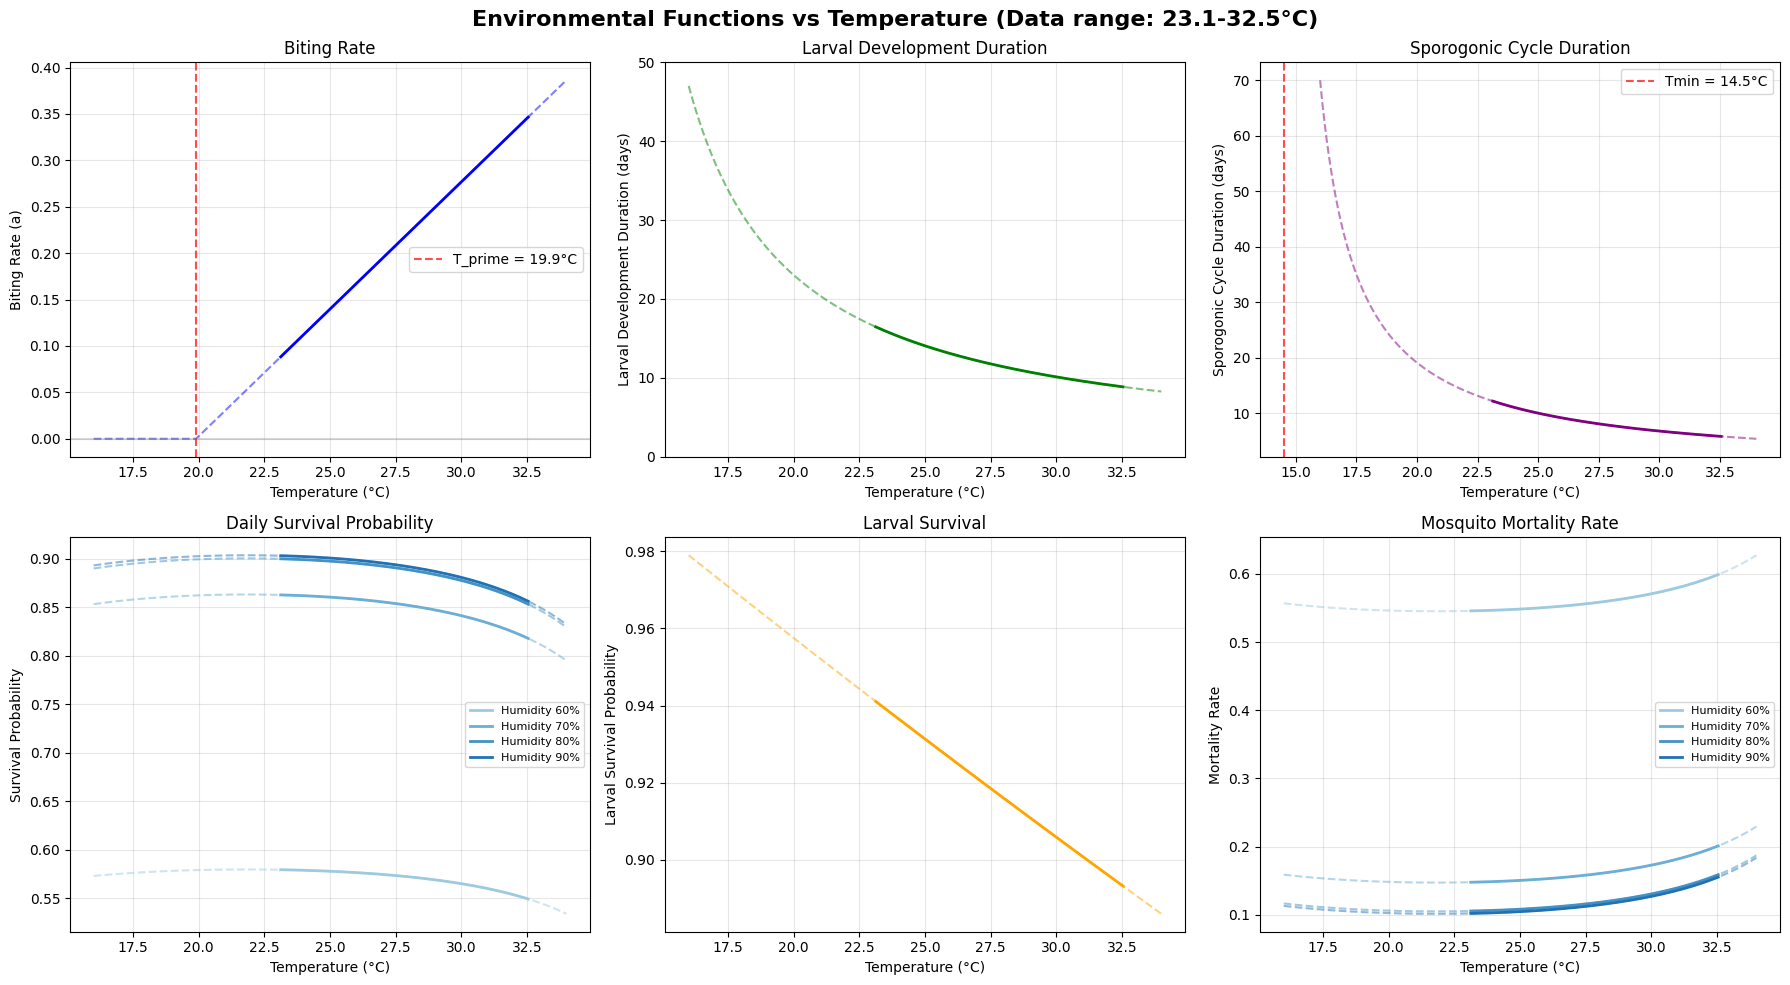

In [6]:
# ============================================================================
# PLOT 1: FUNCTIONS VS TEMPERATURE (using actual data range)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Environmental Functions vs Temperature (Data range: {temp_actual.min():.1f}-{temp_actual.max():.1f}°C)', fontsize=16, fontweight='bold')

temp_range = np.linspace(temp_actual.min(), temp_actual.max(), 200)
temp_range_ext = np.linspace(critical_min_temp_anop, critical_max_temp_anop, 400)
rain_fixed = rain_actual.mean()
humid_fixed = humid_actual.mean()

# 1. Biting rate a(Temp)
ax = axes[0, 0]
ax.plot(temp_range_ext, [a(T) for T in temp_range_ext], 'b--', linewidth=1.5, alpha=0.5)
ax.plot(temp_range, [a(T) for T in temp_range], 'b-', linewidth=2)
ax.axvline(x=T_prime, color='r', linestyle='--', alpha=0.7, label=f'T_prime = {T_prime}°C')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Biting Rate (a)')
ax.set_title('Biting Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Larval development duration tau_L(Temp)
ax = axes[0, 1]
ax.plot(temp_range_ext, [tau_L(T) for T in temp_range_ext], 'g--', linewidth=1.5, alpha=0.5)
ax.plot(temp_range, [tau_L(T) for T in temp_range], 'g-', linewidth=2)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Larval Development Duration (days)')
ax.set_title('Larval Development Duration')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 50)

# 3. Sporogonic cycle duration tau_M(Temp)
ax = axes[0, 2]
ax.plot(temp_range_ext, [tau_M(T) for T in temp_range_ext], 'purple', linestyle='--', linewidth=1.5, alpha=0.5)
ax.plot(temp_range, [tau_M(T) for T in temp_range], 'purple', linewidth=2)
ax.axvline(x=Tmin, color='r', linestyle='--', alpha=0.7, label=f'Tmin = {Tmin}°C')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Sporogonic Cycle Duration (days)')
ax.set_title('Sporogonic Cycle Duration')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Survival probability p_T(Temp, humidity)
ax = axes[1, 0]
humidities = [60, 70, 80, 90]
colors = ['#9ecae1', '#6baed6', '#4292c6', '#2171b5']
for hum, color in zip(humidities, colors):
    ax.plot(temp_range_ext, [p_T(T, hum) for T in temp_range_ext], color=color, linestyle='--', linewidth=1.5, alpha=0.5)
    ax.plot(temp_range, [p_T(T, hum) for T in temp_range], color=color, linewidth=2, label=f'Humidity {hum}%')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Survival Probability')
ax.set_title('Daily Survival Probability')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

# 5. Larval survival p_LT(Temp)
ax = axes[1, 1]
ax.plot(temp_range_ext, [p_LT(T) for T in temp_range_ext], 'orange', linestyle='--', linewidth=1.5, alpha=0.5)
ax.plot(temp_range, [p_LT(T) for T in temp_range], 'orange', linewidth=2)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Larval Survival Probability')
ax.set_title('Larval Survival')
ax.grid(True, alpha=0.3)

# 6. Mortality rate mu(Temp, humidity)
ax = axes[1, 2]
for hum, color in zip(humidities, colors):
    ax.plot(temp_range_ext, [mu(T, hum) for T in temp_range_ext], color=color, linestyle='--', linewidth=1.5, alpha=0.5)
    ax.plot(temp_range, [mu(T, hum) for T in temp_range], color=color, linewidth=2, label=f'Humidity {hum}%')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Mortality Rate')
ax.set_title('Mosquito Mortality Rate')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


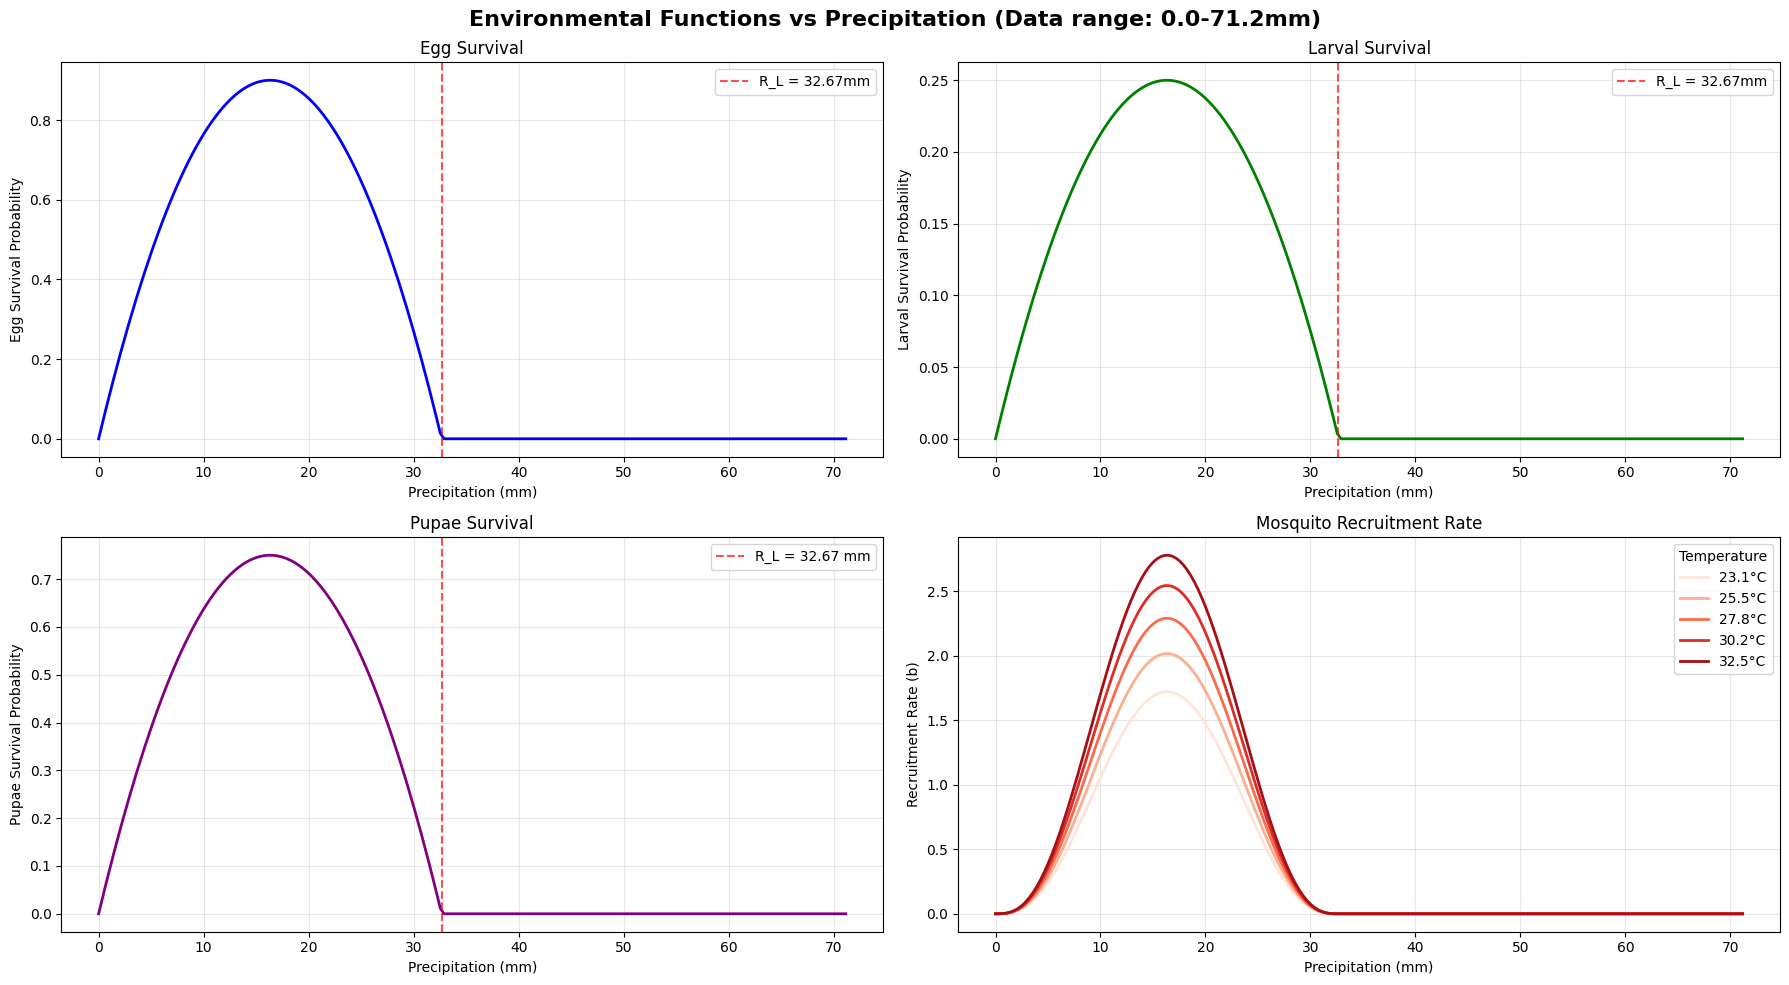

In [7]:
# ============================================================================
# PLOT 2: FUNCTIONS VS PRECIPITATION (using actual data range)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle(f'Environmental Functions vs Precipitation (Data range: {rain_actual.min():.1f}-{rain_actual.max():.1f}mm)', fontsize=16, fontweight='bold')

rain_range = np.linspace(max(0, rain_actual.min()), rain_actual.max(), 200)
temp_fixed = temp_actual.mean()

# 1. Egg survival p_ER(Rain)
ax = axes[0, 0]
ax.plot(rain_range, [p_ER(R, R_L) for R in rain_range], 'b-', linewidth=2)
ax.axvline(x=R_L, color='r', linestyle='--', alpha=0.7, label=f'R_L = {R_L}mm')
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Egg Survival Probability')
ax.set_title('Egg Survival')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Larval survival p_LR(Rain)
ax = axes[0, 1]
ax.plot(rain_range, [p_LR(R, R_L) for R in rain_range], 'g-', linewidth=2)
ax.axvline(x=R_L, color='r', linestyle='--', alpha=0.7, label=f'R_L = {R_L}mm')
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Larval Survival Probability')
ax.set_title('Larval Survival')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Pupae survival p_PR(Rain)
ax = axes[1, 0]
ax.plot(rain_range, [p_PR(R, R_L) for R in rain_range], 'purple', linewidth=2)
ax.axvline(x=R_L, color='r', linestyle='--', alpha=0.7, label=f'R_L = {R_L} mm')
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Pupae Survival Probability')
ax.set_title('Pupae Survival')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Recruitment rate b_rate(Rain, Temp)
ax = axes[1, 1]
temps = [temp_actual.min() + i * (temp_actual.max() - temp_actual.min()) / 4 for i in range(5)]
colors = ['#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']
for temp, color in zip(temps, colors):
    ax.plot(rain_range, [b_rate(R, temp, R_L) for R in rain_range], color=color, linewidth=2, label=f'{temp:.1f}°C')
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Recruitment Rate (b)')
ax.set_title('Mosquito Recruitment Rate')
ax.legend(title='Temperature')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


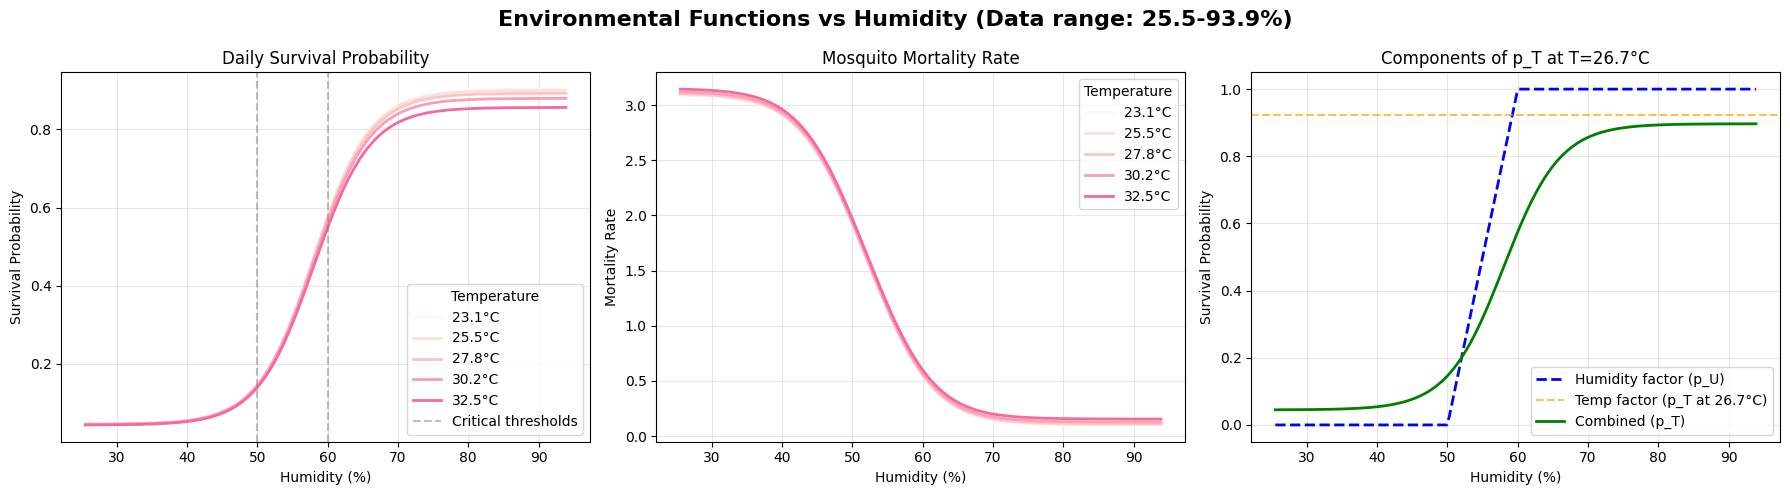

In [8]:
# ============================================================================
# PLOT 3: FUNCTIONS VS HUMIDITY (using actual data range)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Environmental Functions vs Humidity (Data range: {humid_actual.min():.1f}-{humid_actual.max():.1f}%)', fontsize=16, fontweight='bold')

humid_range = np.linspace(max(0, humid_actual.min()), min(100, humid_actual.max()), 200)
temp_fixed = temp_actual.mean()

# 1. Survival probability
ax = axes[0]
temperatures = [temp_actual.min() + i * (temp_actual.max() - temp_actual.min()) / 4 for i in range(5)]
colors = ['#fff7fb', '#fde0dd', '#fcc5c0', '#fa9fb5', '#f768a1']
for temp, color in zip(temperatures, colors):
    ax.plot(humid_range, [p_T(temp, h) for h in humid_range], color=color, linewidth=2, label=f'{temp:.1f}°C')
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=60, color='gray', linestyle='--', alpha=0.5, label='Critical thresholds')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Survival Probability')
ax.set_title('Daily Survival Probability')
ax.legend(title='Temperature', loc='lower right')
ax.grid(True, alpha=0.3)

# 2. Mortality rate
ax = axes[1]
for temp, color in zip(temperatures, colors):
    ax.plot(humid_range, [mu(temp, h) for h in humid_range], color=color, linewidth=2, label=f'{temp:.1f}°C')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Mortality Rate')
ax.set_title('Mosquito Mortality Rate')
ax.legend(title='Temperature')
ax.grid(True, alpha=0.3)

# 3. Combined survival components
ax = axes[2]
p_T_temp_only = [np.exp(-(c1 * temp_fixed + c2)) if c1 * temp_fixed + c2 < 10 else 0 for _ in humid_range]
p_H_only = [0 if h < 50 else (h - 50) / 10 if h < 60 else 1 for h in humid_range]
p_T_combined = [p_T(temp_fixed, h) for h in humid_range]
ax.plot(humid_range, p_H_only, 'b--', linewidth=2, label='Humidity factor (p_H)')
ax.axhline(y=p_T_temp_only[0], color='orange', linestyle='--', alpha=0.7, label=f'Temp factor (p_T at {temp_fixed:.1f}°C)')
ax.plot(humid_range, p_T_combined, 'g-', linewidth=2, label='Combined (p_T)')
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Survival Probability')
ax.set_title(f'Components of p_T at T={temp_fixed:.1f}°C')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


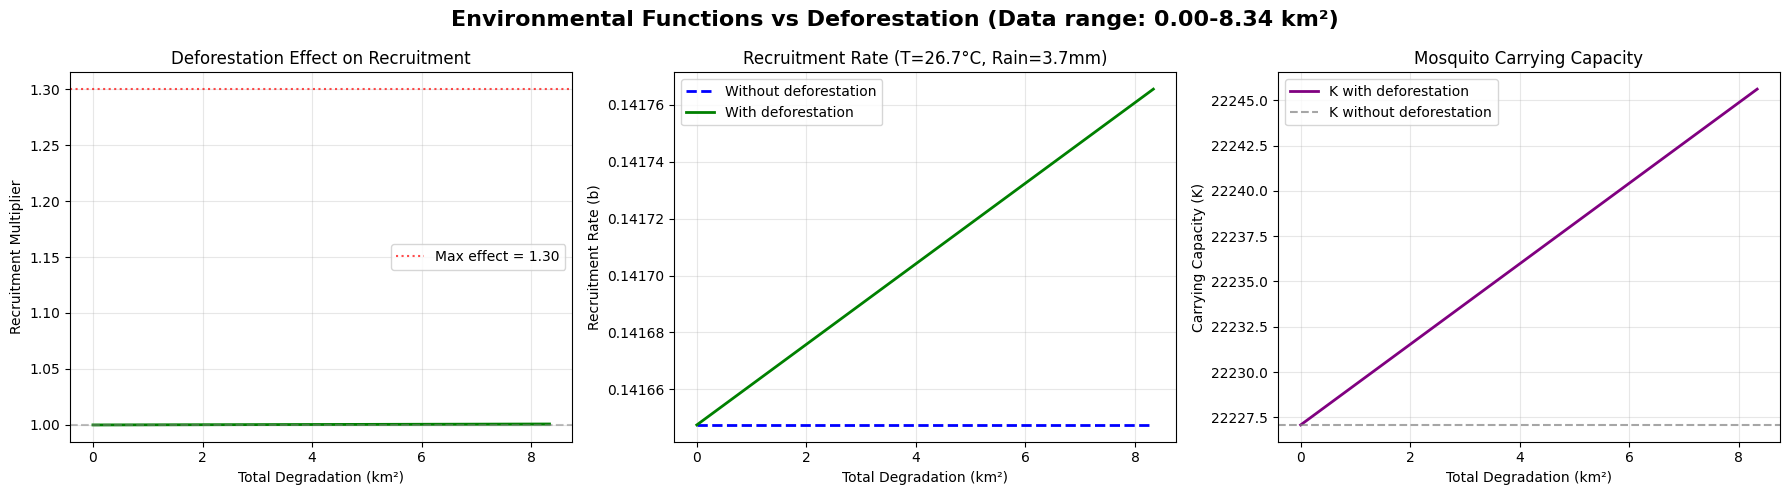

In [9]:
# ============================================================================
# PLOT 4: FUNCTIONS VS DEFORESTATION (using actual data range)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Environmental Functions vs Deforestation (Data range: {defor_actual.min():.2f}-{defor_actual.max():.2f} km\u00B2)', fontsize=16, fontweight='bold')

defor_range = np.linspace(0, min(10, defor_actual.max()), 200)
temp_fixed = temp_actual.mean()
rain_fixed = rain_actual.mean()
fire_fixed = 0

# 1. Deforestation effect on recruitment
ax = axes[0]
recruitment_effect = [1 + min(d * defor_scale, defor_max_effect) for d in defor_range]
ax.plot(defor_range, recruitment_effect, 'g-', linewidth=2)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=1 + defor_max_effect, color='r', linestyle=':', alpha=0.7, label=f'Max effect = {1 + defor_max_effect:.2f}')
ax.fill_between(defor_range, 1, recruitment_effect, alpha=0.3, color='green')
ax.set_xlabel('Total Degradation (km\u00B2)')
ax.set_ylabel('Recruitment Multiplier')
ax.set_title('Deforestation Effect on Recruitment')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Recruitment rate with deforestation
ax = axes[1]
b_no_defor = [b_rate(rain_fixed, temp_fixed, R_L) for _ in defor_range]
b_with_defor = [b_rate_with_environment(rain_fixed, temp_fixed, R_L, fire_fixed, d) for d in defor_range]
ax.plot(defor_range, b_no_defor, 'b--', linewidth=2, label='Without deforestation')
ax.plot(defor_range, b_with_defor, 'g-', linewidth=2, label='With deforestation')
ax.set_xlabel('Total Degradation (km\u00B2)')
ax.set_ylabel('Recruitment Rate (b)')
ax.set_title(f'Recruitment Rate (T={temp_fixed:.1f}°C, Rain={rain_fixed:.1f}mm)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Carrying capacity effect
ax = axes[2]
base_K = 100000
temp_factor = max(0.1, min(1, (temp_fixed - 15) / 15))
rain_factor = min(1, max(0, rain_fixed / R_L))
seasonal_factor = 2.5
K_base = base_K * temp_factor * rain_factor * seasonal_factor
K_with_defor = [K_base * (1 + min(d * defor_scale, defor_max_effect)) for d in defor_range]
ax.plot(defor_range, K_with_defor, 'purple', linewidth=2, label='K with deforestation')
ax.axhline(y=K_base, color='gray', linestyle='--', alpha=0.7, label='K without deforestation')
ax.set_xlabel('Total Degradation (km\u00B2)')
ax.set_ylabel('Carrying Capacity (K)')
ax.set_title('Mosquito Carrying Capacity')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


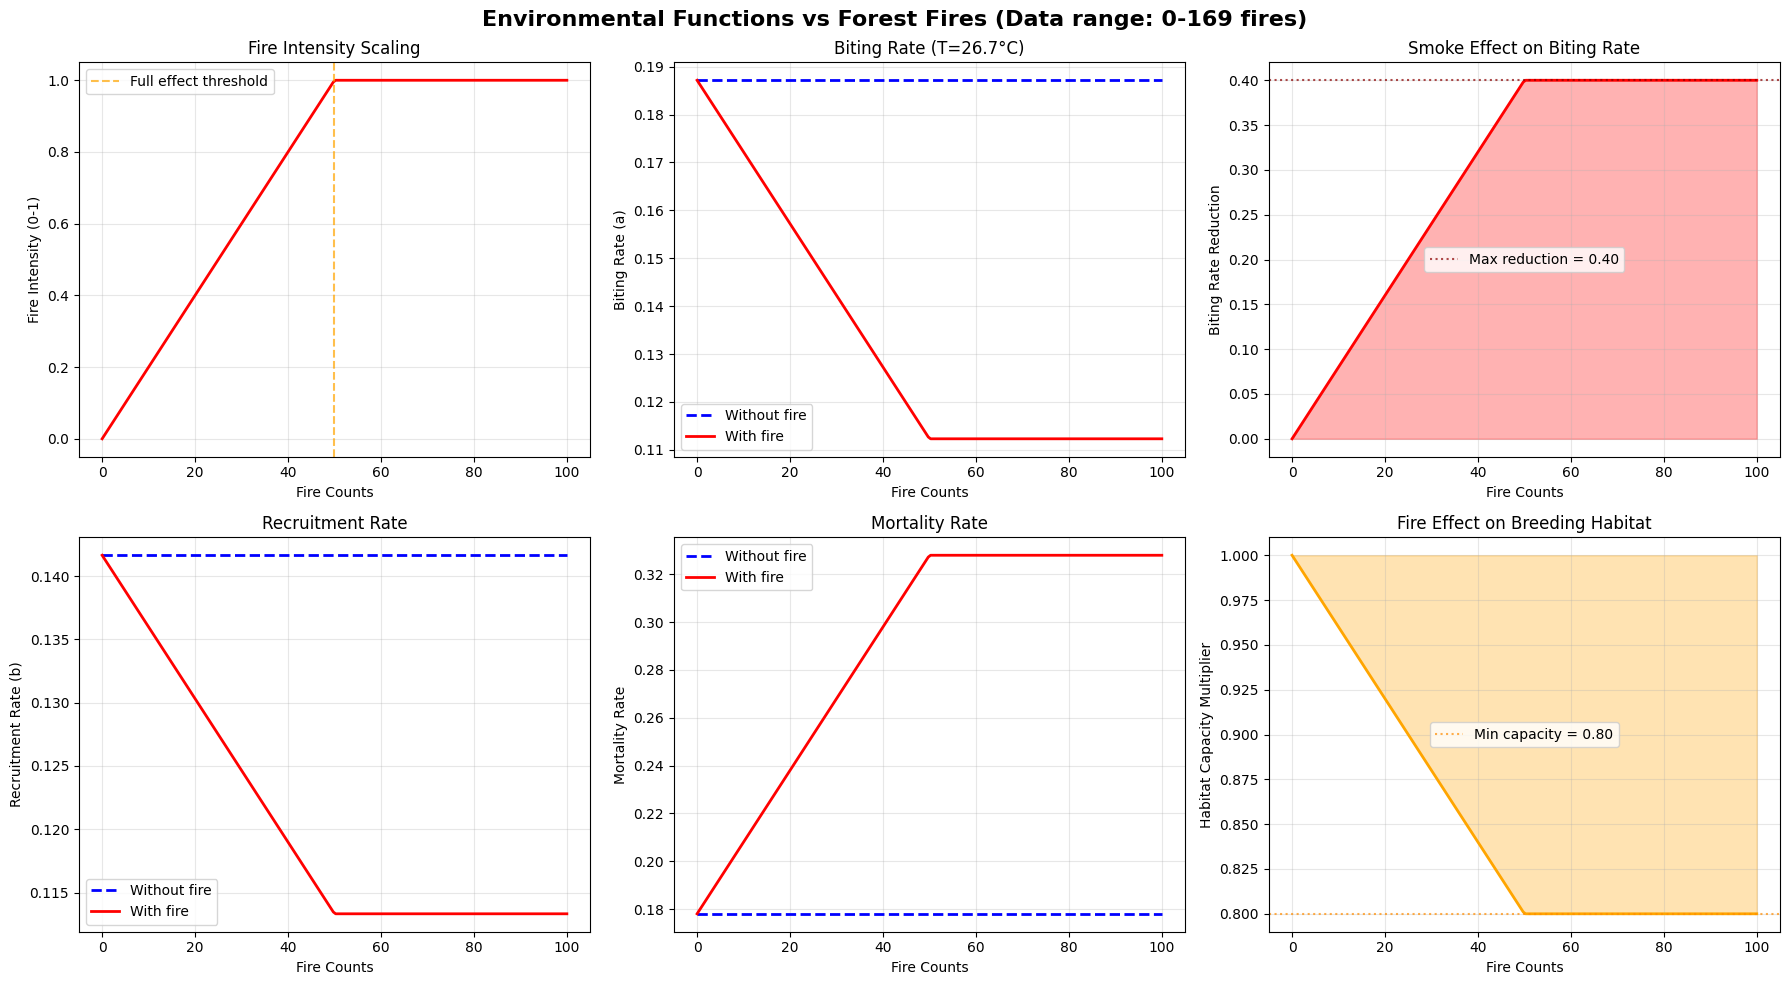

In [10]:
# ============================================================================
# PLOT 5: FUNCTIONS VS FOREST FIRES (using actual data range)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Environmental Functions vs Forest Fires (Data range: {fire_actual.min():.0f}-{fire_actual.max():.0f} fires)', fontsize=16, fontweight='bold')

fire_range = np.linspace(0, min(100, fire_actual.max()), 200)
temp_fixed = temp_actual.mean()
humid_fixed = humid_actual.mean()
rain_fixed = rain_actual.mean()
defor_fixed = 0

# 1. Fire intensity scaling
ax = axes[0, 0]
fire_intensity = [min(f / 50.0, 1.0) for f in fire_range]
ax.plot(fire_range, fire_intensity, 'r-', linewidth=2)
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.7, label='Full effect threshold')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Fire Intensity (0-1)')
ax.set_title('Fire Intensity Scaling')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Biting rate with fire effect
ax = axes[0, 1]
a_base = [a(temp_fixed) for _ in fire_range]
a_with_fire_effect = [a_with_fire(temp_fixed, f, fire_smoke_effect) for f in fire_range]
ax.plot(fire_range, a_base, 'b--', linewidth=2, label='Without fire')
ax.plot(fire_range, a_with_fire_effect, 'r-', linewidth=2, label='With fire')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Biting Rate (a)')
ax.set_title(f'Biting Rate (T={temp_fixed:.1f}°C)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Biting rate reduction
ax = axes[0, 2]
reduction = [fire_smoke_effect * min(f / 50.0, 1.0) for f in fire_range]
ax.plot(fire_range, reduction, 'r-', linewidth=2)
ax.fill_between(fire_range, 0, reduction, alpha=0.3, color='red')
ax.axhline(y=fire_smoke_effect, color='darkred', linestyle=':', alpha=0.7, label=f'Max reduction = {fire_smoke_effect:.2f}')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Biting Rate Reduction')
ax.set_title('Smoke Effect on Biting Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Recruitment rate with fire effect
ax = axes[1, 0]
b_base = [b_rate(rain_fixed, temp_fixed, R_L) for _ in fire_range]
b_with_fire = [b_rate_with_environment(rain_fixed, temp_fixed, R_L, f, defor_fixed) for f in fire_range]
ax.plot(fire_range, b_base, 'b--', linewidth=2, label='Without fire')
ax.plot(fire_range, b_with_fire, 'r-', linewidth=2, label='With fire')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Recruitment Rate (b)')
ax.set_title('Recruitment Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Mortality rate with fire effect
ax = axes[1, 1]
mu_base = [mu(temp_fixed, humid_fixed) for _ in fire_range]
mu_with_fire_effect = [mu_with_fire(temp_fixed, humid_fixed, f, fire_habitat_effect) for f in fire_range]
ax.plot(fire_range, mu_base, 'b--', linewidth=2, label='Without fire')
ax.plot(fire_range, mu_with_fire_effect, 'r-', linewidth=2, label='With fire')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Mortality Rate')
ax.set_title('Mortality Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Net habitat effect
ax = axes[1, 2]
habitat_effect = [1 - fire_habitat_effect * min(f / 50.0, 1.0) for f in fire_range]
ax.plot(fire_range, habitat_effect, 'orange', linewidth=2)
ax.fill_between(fire_range, habitat_effect, 1, alpha=0.3, color='orange')
ax.axhline(y=1 - fire_habitat_effect, color='darkorange', linestyle=':', alpha=0.7, label=f'Min capacity = {1 - fire_habitat_effect:.2f}')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Habitat Capacity Multiplier')
ax.set_title('Fire Effect on Breeding Habitat')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


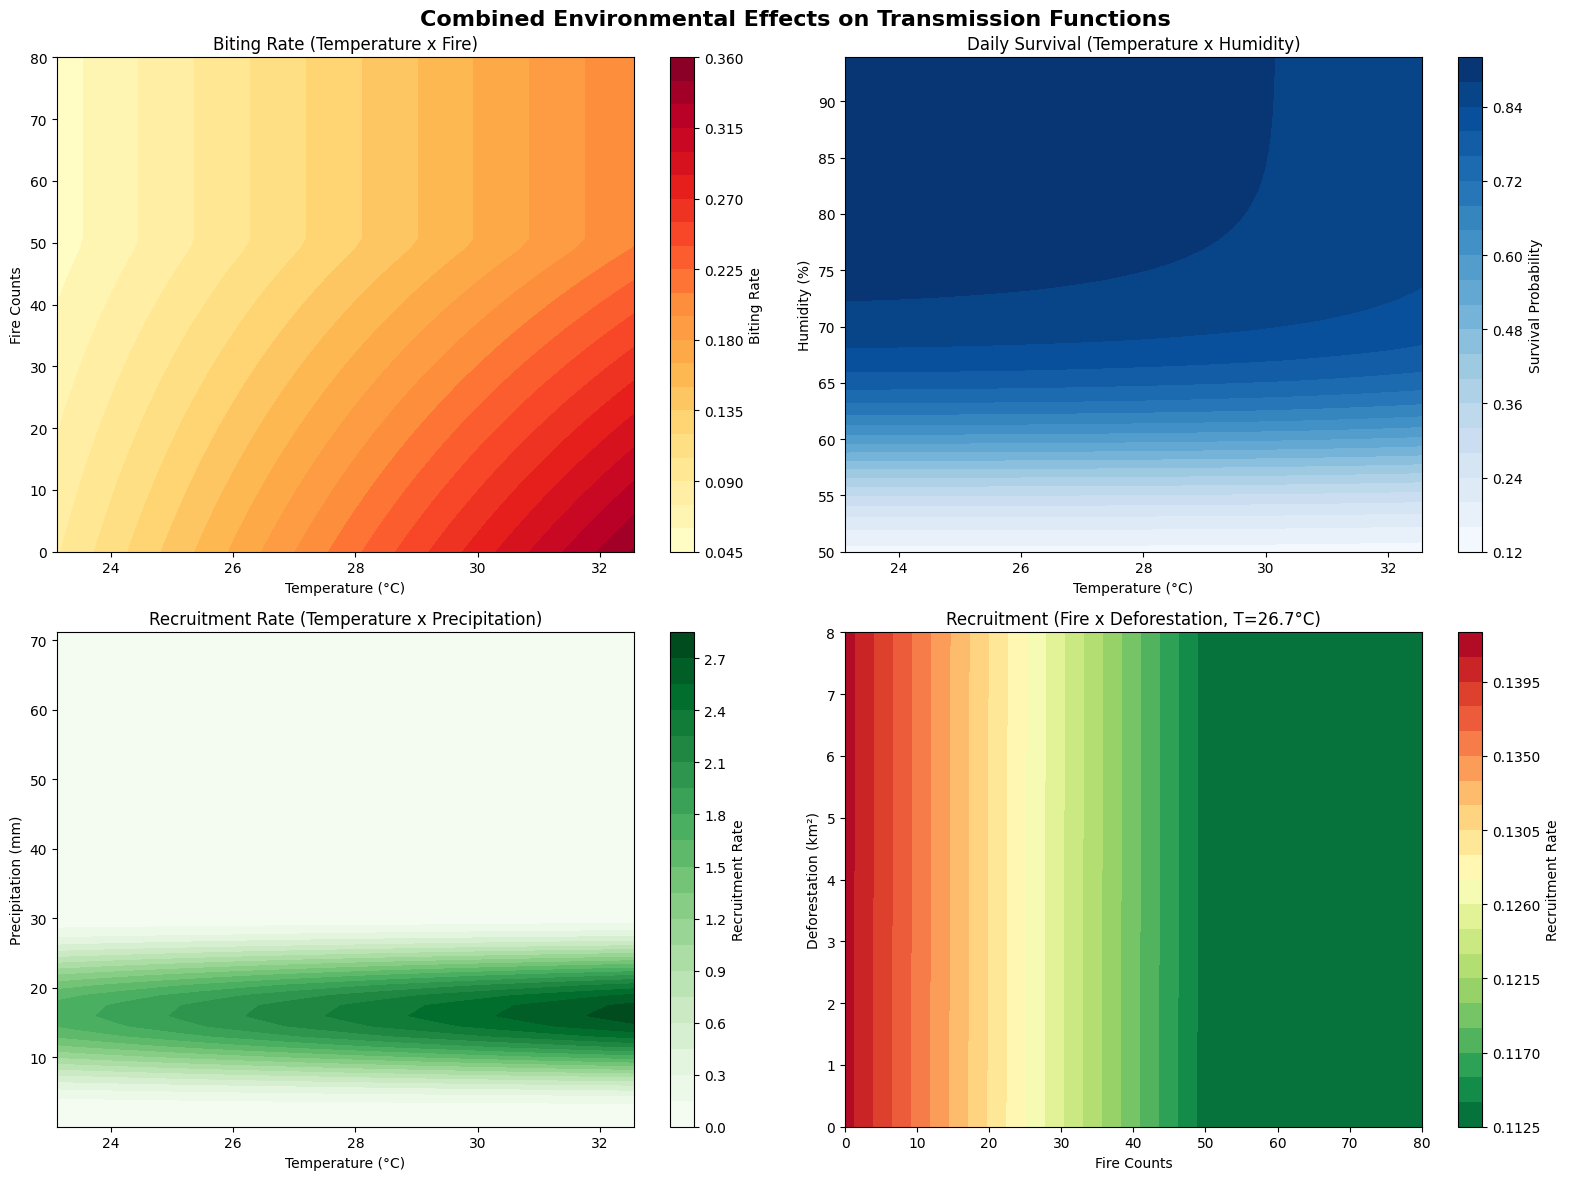

In [11]:
# ============================================================================
# PLOT 6: COMBINED ENVIRONMENTAL EFFECTS (using actual data ranges)
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Combined Environmental Effects on Transmission Functions', fontsize=16, fontweight='bold')

temp_range = np.linspace(temp_actual.min(), temp_actual.max(), 50)
humid_range = np.linspace(max(50, humid_actual.min()), min(100, humid_actual.max()), 50)
rain_range = np.linspace(max(0, rain_actual.min()), rain_actual.max(), 50)
fire_range = np.linspace(0, min(80, fire_actual.max()), 50)
defor_range = np.linspace(0, min(8, defor_actual.max()), 50)

# 1. Biting rate: Temperature and Fire combined
ax = axes[0, 0]
T_mesh = np.meshgrid(temp_range, fire_range)[0]
F_mesh = np.meshgrid(temp_range, fire_range)[1]
a_combined = np.array([[a_with_fire(T, F, fire_smoke_effect) for T in temp_range] for F in fire_range])
contour = ax.contourf(temp_range, fire_range, a_combined, levels=20, cmap='YlOrRd')
plt.colorbar(contour, ax=ax, label='Biting Rate')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Fire Counts')
ax.set_title('Biting Rate (Temperature x Fire)')

# 2. Survival: Temperature and Humidity combined
ax = axes[0, 1]
T_mesh = np.meshgrid(temp_range, humid_range)[0]
H_mesh = np.meshgrid(temp_range, humid_range)[1]
p_T_combined = np.array([[p_T(T, H) for T in temp_range] for H in humid_range])
contour = ax.contourf(temp_range, humid_range, p_T_combined, levels=20, cmap='Blues')
plt.colorbar(contour, ax=ax, label='Survival Probability')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Humidity (%)')
ax.set_title('Daily Survival (Temperature x Humidity)')

# 3. Recruitment: Temperature and Precipitation combined
ax = axes[1, 0]
T_mesh = np.meshgrid(temp_range, rain_range)[0]
R_mesh = np.meshgrid(temp_range, rain_range)[1]
b_combined = np.array([[b_rate(R, T, R_L) for T in temp_range] for R in rain_range])
contour = ax.contourf(temp_range, rain_range, b_combined, levels=20, cmap='Greens')
plt.colorbar(contour, ax=ax, label='Recruitment Rate')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Precipitation (mm)')
ax.set_title('Recruitment Rate (Temperature x Precipitation)')

# 4. Full recruitment with all environmental factors
ax = axes[1, 1]
temp_fixed = temp_actual.mean()
rain_fixed = rain_actual.mean()
F_mesh, D_mesh = np.meshgrid(fire_range, defor_range)
b_full = np.array([[b_rate_with_environment(rain_fixed, temp_fixed, R_L, F, D) for F in fire_range] for D in defor_range])
contour = ax.contourf(fire_range, defor_range, b_full, levels=20, cmap='RdYlGn_r')
plt.colorbar(contour, ax=ax, label='Recruitment Rate')
ax.set_xlabel('Fire Counts')
ax.set_ylabel('Deforestation (km\u00B2)')
ax.set_title(f'Recruitment (Fire x Deforestation, T={temp_fixed:.1f}°C)')

plt.tight_layout()
plt.show()


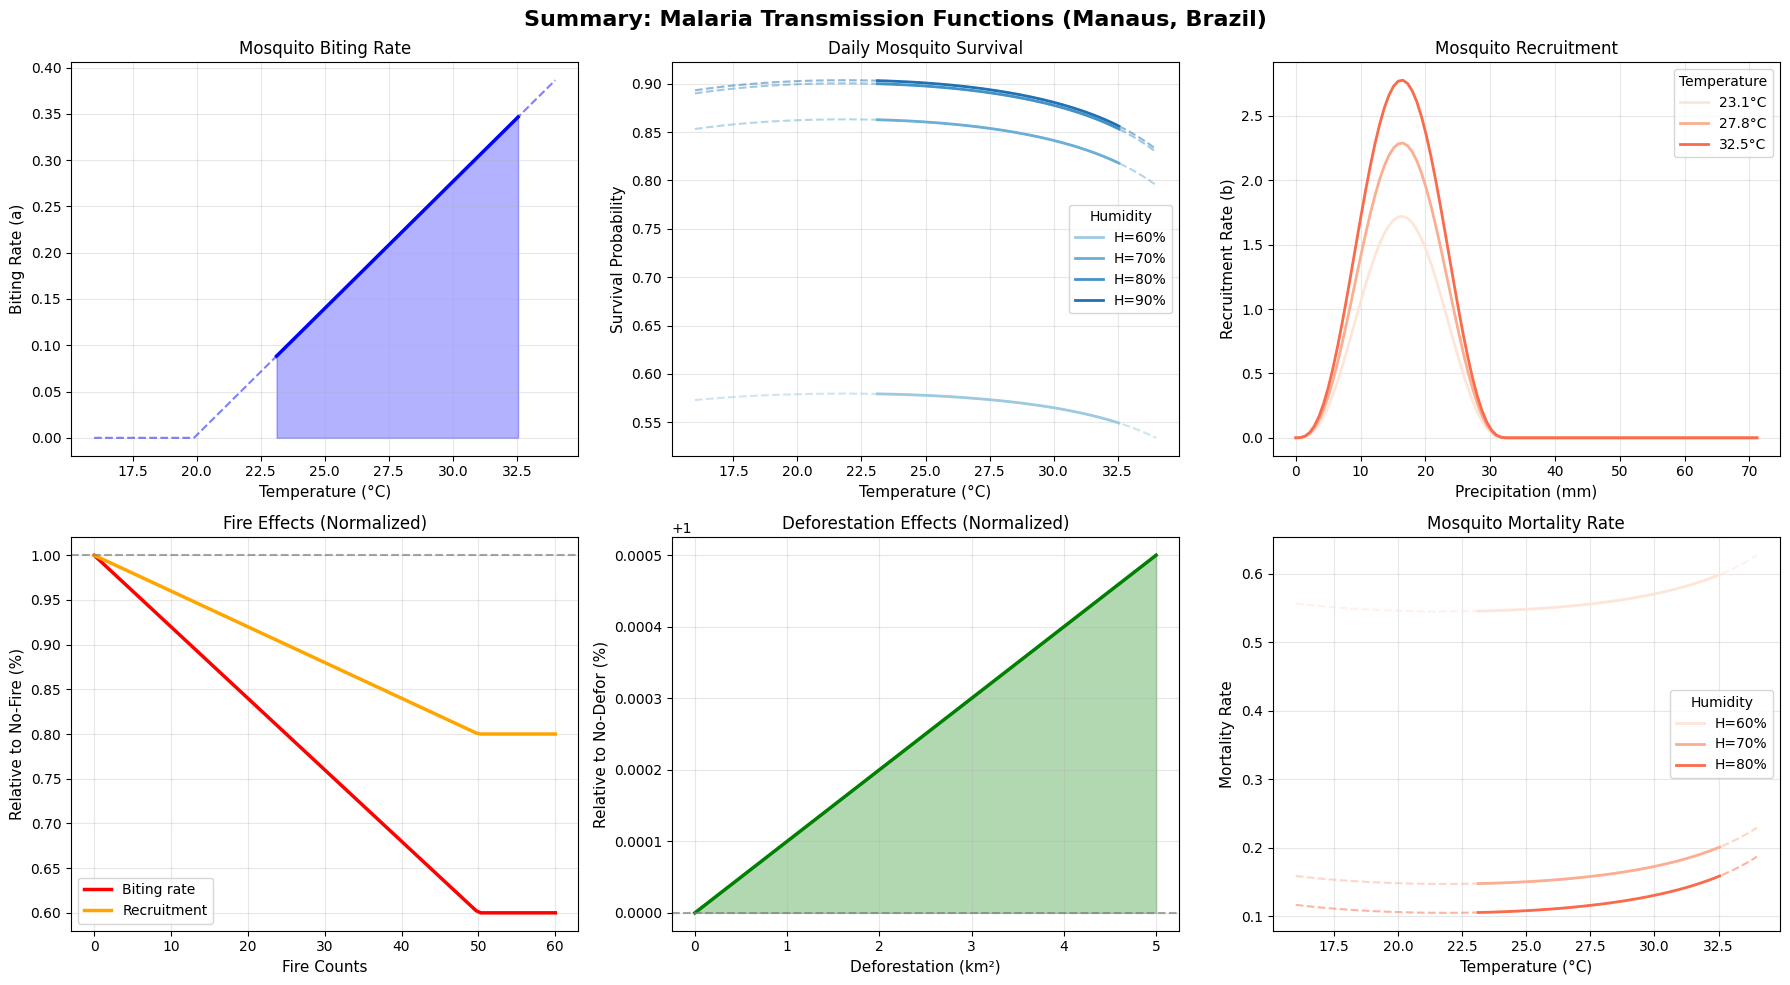


ENVIRONMENTAL FUNCTIONS SUMMARY

TEMPERATURE DEPENDENT:
  - Biting rate (a): Increases with temperature above T_prime=25.6°C
  - Larval development (tau_L): Faster at higher temperatures
  - Sporogonic cycle (tau_M): Shorter at higher temperatures
  - Survival (p_T): Optimal around 25-30°C
  - Mortality (mu): Increases at temperature extremes

HUMIDITY DEPENDENT:
  - Below 50%: Zero survival
  - 50-60%: Linear increase
  - Above 60%: Full survival

PRECIPITATION DEPENDENT:
  - Egg/Larval/Pupae survival: Peak at R_L/2mm
  - Recruitment: Optimal around moderate rainfall

DEFORESTATION EFFECTS:
  - Increases breeding sites (puddles)
  - Up to 30% increase in transmission
  - Delayed effect (~14 days)

FIRE EFFECTS:
  - Smoke reduces biting rate (up to 40%)
  - Destroys breeding habitats (up to 20%)
  - Post-fire recovery (~21 days)



In [12]:
# ============================================================================
# PLOT 7: SUMMARY - All Functions with Actual Environmental Ranges
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Summary: Malaria Transmission Functions (Manaus, Brazil)', fontsize=16, fontweight='bold')

temp_range = np.linspace(temp_actual.min(), temp_actual.max(), 100)
temp_range_ext = np.linspace(critical_min_temp_anop, critical_max_temp_anop, 400)
humid_range = np.linspace(max(50, humid_actual.min()), min(100, humid_actual.max()), 100)
rain_range = np.linspace(max(0, rain_actual.min()), rain_actual.max(), 100)
fire_range = np.linspace(0, min(60, fire_actual.max()), 100)
defor_range = np.linspace(0, min(5, defor_actual.max()), 100)

# 1. Biting Rate
ax = axes[0, 0]
ax.plot(temp_range_ext, [a(T) for T in temp_range_ext], 'b--', linewidth=1.5, alpha=0.5)
ax.plot(temp_range, [a(T) for T in temp_range], 'b-', linewidth=2.5)
ax.fill_between(temp_range, 0, [a(T) for T in temp_range], alpha=0.3, color='blue')
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Biting Rate (a)', fontsize=11)
ax.set_title('Mosquito Biting Rate', fontsize=12)
ax.grid(True, alpha=0.3)

# 2. Mosquito Survival
ax = axes[0, 1]
humidities = [60, 70, 80, 90]
colors = ['#9ecae1', '#6baed6', '#4292c6', '#2171b5']
for hum, color in zip(humidities, colors):
    ax.plot(temp_range_ext, [p_T(T, hum) for T in temp_range_ext], color=color, linestyle='--', linewidth=1.5, alpha=0.5)
    ax.plot(temp_range, [p_T(T, hum) for T in temp_range], color=color, linewidth=2, label=f'H={hum}%')
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Survival Probability', fontsize=11)
ax.set_title('Daily Mosquito Survival', fontsize=12)
ax.legend(title='Humidity')
ax.grid(True, alpha=0.3)

# 3. Recruitment Rate
ax = axes[0, 2]
temps = [temp_actual.min() + i * (temp_actual.max() - temp_actual.min()) / 2 for i in range(3)]
colors = ['#fee5d9', '#fcae91', '#fb6a4a']
for t, c in zip(temps, colors):
    ax.plot(rain_range, [b_rate(R, t, R_L) for R in rain_range], color=c, linewidth=2, label=f'{t:.1f}°C')
ax.set_xlabel('Precipitation (mm)', fontsize=11)
ax.set_ylabel('Recruitment Rate (b)', fontsize=11)
ax.set_title('Mosquito Recruitment', fontsize=12)
ax.legend(title='Temperature')
ax.grid(True, alpha=0.3)

# 4. Fire Effects
ax = axes[1, 0]
base_biting = a(temp_actual.mean())
biting_w_fire = [a_with_fire(temp_actual.mean(), f, fire_smoke_effect) for f in fire_range]
base_recruit = b_rate(rain_actual.mean(), temp_actual.mean(), R_L)
recruit_w_fire = [b_rate_with_environment(rain_actual.mean(), temp_actual.mean(), R_L, f, 0) for f in fire_range]
ax.plot(fire_range, [x/base_biting for x in biting_w_fire], 'r-', linewidth=2.5, label='Biting rate')
ax.plot(fire_range, [x/base_recruit for x in recruit_w_fire], 'orange', linewidth=2.5, label='Recruitment')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Fire Counts', fontsize=11)
ax.set_ylabel('Relative to No-Fire (%)', fontsize=11)
ax.set_title('Fire Effects (Normalized)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Deforestation Effects
ax = axes[1, 1]
base_recruit = b_rate(rain_actual.mean(), temp_actual.mean(), R_L)
recruit_w_defor = [b_rate_with_environment(rain_actual.mean(), temp_actual.mean(), R_L, 0, d) for d in defor_range]
ax.plot(defor_range, [x/base_recruit for x in recruit_w_defor], 'g-', linewidth=2.5)
ax.fill_between(defor_range, 1, [x/base_recruit for x in recruit_w_defor], alpha=0.3, color='green')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Deforestation (km\u00B2)', fontsize=11)
ax.set_ylabel('Relative to No-Defor (%)', fontsize=11)
ax.set_title('Deforestation Effects (Normalized)', fontsize=12)
ax.grid(True, alpha=0.3)

# 6. Mortality Rate
ax = axes[1, 2]
for hum, color in zip(humidities, colors):
    ax.plot(temp_range_ext, [mu(T, hum) for T in temp_range_ext], color=color, linestyle='--', linewidth=1.5, alpha=0.5)
    ax.plot(temp_range, [mu(T, hum) for T in temp_range], color=color, linewidth=2, label=f'H={hum}%')
ax.set_xlabel('Temperature (°C)', fontsize=11)
ax.set_ylabel('Mortality Rate', fontsize=11)
ax.set_title('Mosquito Mortality Rate', fontsize=12)
ax.legend(title='Humidity')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('ENVIRONMENTAL FUNCTIONS SUMMARY')
print('='*70)
print('''
TEMPERATURE DEPENDENT:
  - Biting rate (a): Increases with temperature above T_prime=25.6°C
  - Larval development (tau_L): Faster at higher temperatures
  - Sporogonic cycle (tau_M): Shorter at higher temperatures
  - Survival (p_T): Optimal around 25-30°C
  - Mortality (mu): Increases at temperature extremes

HUMIDITY DEPENDENT:
  - Below 50%: Zero survival
  - 50-60%: Linear increase
  - Above 60%: Full survival

PRECIPITATION DEPENDENT:
  - Egg/Larval/Pupae survival: Peak at R_L/2mm
  - Recruitment: Optimal around moderate rainfall

DEFORESTATION EFFECTS:
  - Increases breeding sites (puddles)
  - Up to 30% increase in transmission
  - Delayed effect (~14 days)

FIRE EFFECTS:
  - Smoke reduces biting rate (up to 40%)
  - Destroys breeding habitats (up to 20%)
  - Post-fire recovery (~21 days)
''')
print('='*70)


In [13]:
# ============================================================================
# TEMPERATURE FACTOR FUNCTIONS FOR CARRYING CAPACITY
# ============================================================================

# ============================================================================
# Function 1: Amazon-Smooth (Fully C1 continuous)
# - Peak at 28°C (optimal development temperature)
# - Smooth sigma transition (8→12) via tanh around peak
# - No sharp boundaries: smooth decay below ~10°C and above ~40°C
# - C1 continuous: no jumps in function or derivative
# ============================================================================
def temp_factor_amazon(T):
    """
    Smooth temperature factor for mosquito carrying capacity.
    - Peak at 28°C (optimal development temperature)
    - C1 continuous: no jumps in function or derivative
    - Smooth sigma transition (8 to 12) around the peak
    - Smooth decay below ~10°C and above ~40°C (no sharp boundaries)
    """
    Topt = 28.0
    Tmin, Tmax = 10.0, 40.0

    # Smoothly varying sigma using tanh (no piecewise!)
    sigma = 10.0 - 2.0 * np.tanh((T - Topt) / 5.0)

    # Smooth decay at boundaries using tanh-based sigmoid (no sharp boundaries!)
    k = 5.0
    sigmoid = lambda x: (1.0 + np.tanh(k * x)) / 2.0

    # Combined exponent
    exponent = -0.5 * ((T - Topt) / sigma)**2
    exponent -= 0.2 * ((Tmin - T) * sigmoid(Tmin - T))**2
    exponent -= 0.2 * ((T - Tmax) * sigmoid(T - Tmax))**2

    return np.exp(exponent)

def temp_factor_asymmetric(T):
    """
    Smooth asymmetric temperature factor (no piecewise conditions).
    - Peak at 26°C
    - Smooth sigma transition: 8 (left) to 12 (right) via tanh
    - C1 continuous everywhere
    """
    Topt = 26.0
    # Smoothly varying sigma using tanh (no piecewise!)
    sigma = 10.0 - 2.0 * np.tanh((T - Topt) / 5.0)
    return np.exp(-0.5 * ((T - Topt) / sigma)**2)

print('Temperature factor functions defined (Amazon-optimized FIXED)!')
print('  - temp_factor_amazon(T): Peak 28°C, fully smooth (C1), tanh transitions')
print('  - temp_factor_smooth(T): Peak 26°C, no boundaries')
print('  - temp_factor_asymmetric(T): Peak 26°C, fully smooth (C1), tanh sigma')


Temperature factor functions defined (Amazon-optimized FIXED)!
  - temp_factor_amazon(T): Peak 28°C, fully smooth (C1), tanh transitions
  - temp_factor_smooth(T): Peak 26°C, no boundaries
  - temp_factor_asymmetric(T): Peak 26°C, fully smooth (C1), tanh sigma


In [14]:
# ============================================================================
# PLOT: temp_factor and rain_factor functions from Test_SEIRS_SEI_ODE.ipynb
# ============================================================================

# Parameters from Test_SEIRS_SEI_ODE.ipynb

# Temperature range
T_vals = np.linspace(5, 45, 401)
R_vals = np.linspace(0, 100, 401)

# ============================================================================
# temp_factor Option 1: Linear function
# ============================================================================
def temp_factor_linear(T):
    return max(0, (T - critical_min_temp_anop) / (optimal_temp_anop - critical_min_temp_anop))

# ============================================================================
# temp_factor Option 2: Standard Briere function (scaled for Anopheles)
# ============================================================================
# def briere_unscaled_anop(T):
#     if T < critical_min_temp_anop or T > critical_max_temp_anop:
#         return 0
#     return T * (T - Tmin) * (critical_max_temp_anop - T)**(1/2)

# # Calculate scaling factor to peak at 1.0 at optimal_temp_anop
# briere_unscaled_at_opt = briere_unscaled_anop(optimal_temp_anop)
# eta_anop = 1.0 / briere_unscaled_at_opt

# def temp_factor_briere(T):
#     if T < critical_min_temp_anop or T > critical_max_temp_anop:
#         return 0.01
#     return eta_anop * briere_unscaled_anop(T)

def temp_factor_briere_normalized(Temp):
    if Temp <= critical_min_temp_anop or Temp >= critical_max_temp_anop:
        return 0.0
    raw = Temp * (Temp - critical_min_temp_anop) * ((critical_max_temp_anop - Temp) ** 0.5)
    opt_raw = optimal_temp_anop * (optimal_temp_anop - critical_min_temp_anop) * ((critical_max_temp_anop - optimal_temp_anop) ** 0.5)
    return min(1.0, raw / opt_raw)

# ============================================================================
# temp_factor Option 3: Piecewise quadratic
# ============================================================================
def temp_factor_piecewise(T):
    if critical_min_temp_anop <= T <= optimal_temp_anop:
        return max(0.01, 1 - ((T - optimal_temp_anop) / (optimal_temp_anop - critical_min_temp_anop))**2)
    elif optimal_temp_anop < T <= critical_max_temp_anop:
        return max(0.01, 1 - ((T - optimal_temp_anop) / (critical_max_temp_anop - optimal_temp_anop))**2)
    else:
        return 0.01

# ============================================================================
# temp_factor Option 4: Asymmetric Gaussian (Amazon-optimized)
# Peak at 28°C, reflects 26.4-30.0°C optimal range
# ============================================================================
def temp_factor_amazon(T):
    Tmin, Tmax = critical_min_temp_anop, critical_max_temp_anop
    Topt = optimal_temp_anop  
    
    # Smooth decay beyond boundaries
    if T < Tmin:
        return np.exp(-((Tmin - T)/4)**2) * 0.01
    if T > Tmax:
        return np.exp(-((T - Tmax)/2)**2) * 0.01
    
    # Different sigma: wider on right (26-30°C optimal range)
    if T <= Topt:
        sigma = 8   # Left side (10-28°C)
    else:
        sigma = 12  # Right side (28-40°C, wider for 26-30 range)
    
    return np.exp(-0.5 * ((T - Topt) / sigma)**2)

# Calculate values for plotting (all functions)
temp_linear = [temp_factor_linear(T) for T in T_vals]
temp_briere = [temp_factor_briere_normalized(T) for T in T_vals]
temp_piecewise = [temp_factor_piecewise(T) for T in T_vals]
temp_amazon = [temp_factor_amazon(T) for T in T_vals]

# ============================================================================
# rain_factor: habitat_creating * habitat_flushing
# ============================================================================
def rain_factor(R):
    habitat_creating = 2 * R / R_L
    habitat_flushing = np.exp(1 - 2 * R / R_L)
    return habitat_creating * habitat_flushing

rain_vals = [rain_factor(R) for R in R_vals]

# ============================================================================
# Plot 1: temp_factor comparisons (all 5 functions)
# ============================================================================
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=T_vals, y=temp_linear,
    mode='lines', name='Linear', line=dict(color='blue', width=2)
))
fig1.add_trace(go.Scatter(
    x=T_vals, y=temp_briere,
    mode='lines', name='Briere (standard)', line=dict(color='red', width=2, dash='dot')
))
# fig1.add_trace(go.Scatter(
#     x=T_vals, y=temp_piecewise,
#     mode='lines', name='Piecewise Quadratic', line=dict(color='green', width=2, dash='dash')
# ))
# fig1.add_trace(go.Scatter(
#     x=T_vals, y=temp_amazon,
#     mode='lines', name='Amazon-Optimized', line=dict(color='cyan', width=3)
# ))

fig1.update_layout(
    xaxis_title='Temperature (°C)',
    yaxis_title='temp_factor (carrying capacity multiplier)',
    height=600,
    showlegend=True,
    yaxis=dict(range=[-0.1, 2.0])
)
# Add vertical lines for key temperatures
fig1.add_vline(x=critical_min_temp_anop, line_dash='dash', line_color='gray', 
             annotation_text=f'Min: {critical_min_temp_anop}°C')
fig1.add_vline(x=optimal_temp_anop, line_dash='dash', line_color='red',
             annotation_text=f'Opt: {optimal_temp_anop}°C')
fig1.add_vline(x=critical_max_temp_anop, line_dash='dash', line_color='gray',
             annotation_text=f'Max: {critical_max_temp_anop}°C')
fig1.show()

# ============================================================================
# Plot 2: rain_factor
# ============================================================================
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=R_vals, y=rain_vals,
    mode='lines', name='rain_factor', line=dict(color='purple', width=2)
))

fig2.update_layout(
    title='Rainfall Factor (rain_factor) Function<br><sup>rain_factor = (2R/R_L) * exp(1 - 2R/R_L), peaks at R = R_L/2</sup>',
    xaxis_title='Precipitation (mm)',
    yaxis_title='rain_factor (carrying capacity multiplier)',
    height=500,
    showlegend=True
)
fig2.add_vline(x=R_L/2, line_dash='dash', line_color='gray',
             annotation_text=f'Peak: R_L/2 = {R_L/2:.1f}mm')
fig2.add_vline(x=R_L, line_dash='dash', line_color='gray',
             annotation_text=f'R_L = {R_L:.1f}mm')
fig2.show()

print('='*70)
print('TEMPERATURE FACTOR SUMMARY')
print('='*70)
print(f'Critical min (Anopheles): {critical_min_temp_anop}°C')
print(f'Optimal temp (Anopheles): {optimal_temp_anop}°C')
print(f'Critical max (Anopheles): {critical_max_temp_anop}°C')
print(f'\nAmazon breeding habitats: 26.4-30.0°C')
print(f'High larval survival at 20°C (slower development)')
print(f'Peak transmission: 24.6-29.4°C')
print(f'\n1. Linear: max(0, (T-10)/16), will be limited by f_R')
print(f'2. Standard Briere: peaks at ~22°C (not 26-30 range!)')
print(f'3. Piecewise: Too perfect, peak at 26°C')
print(f'4. Amazon-Optimized: Peak 28°C, wide 26-30°C range')

print('\n' + '='*70)
print('RAINFALL FACTOR SUMMARY')
print('='*70)
print(f'R_L = {R_L} mm')
print(f'rain_factor = (2R/R_L) * exp(1 - 2R/R_L)')
print(f'Peaks at R = R_L/2 = {R_L/2} mm')
print(f'At R=0: rain_factor = {(2*0/R_L)*np.exp(1 - (2*0/R_L)):.3f}')
print(f'At R=R_L/2: rain_factor = {(2*(R_L/2)/R_L)*np.exp(1 - (2*(R_L/2)/R_L)):.3f}')
print(f'At R=R_L: rain_factor = {(2*R_L/R_L)*np.exp(1 - (2*R_L/R_L)):.3f}')
print(f'At R=2*R_L: rain_factor = {(2*2*R_L/R_L)*np.exp(1 - (2*2*R_L/R_L)):.3f}')


TEMPERATURE FACTOR SUMMARY
Critical min (Anopheles): 16°C
Optimal temp (Anopheles): 25°C
Critical max (Anopheles): 34°C

Amazon breeding habitats: 26.4-30.0°C
High larval survival at 20°C (slower development)
Peak transmission: 24.6-29.4°C

1. Linear: max(0, (T-10)/16), will be limited by f_R
2. Standard Briere: peaks at ~22°C (not 26-30 range!)
3. Piecewise: Too perfect, peak at 26°C
4. Amazon-Optimized: Peak 28°C, wide 26-30°C range

RAINFALL FACTOR SUMMARY
R_L = 32.67 mm
rain_factor = (2R/R_L) * exp(1 - 2R/R_L)
Peaks at R = R_L/2 = 16.335 mm
At R=0: rain_factor = 0.000
At R=R_L/2: rain_factor = 1.000
At R=R_L: rain_factor = 0.736
At R=2*R_L: rain_factor = 0.199
